In [1]:
import pandas as pd
import numpy as np
import h5py
from few.utils.mappings.jacobian import ELdot_to_PEdot_Jacobian
from few.utils.mappings.kerrecceq import apex_of_uwyz_nex, _uwyz_of_apex_kernel_nex, DELTAPMIN_REGIONC
from few.utils.geodesic import get_fundamental_frequencies, get_separatrix
from multispline.spline import BicubicSpline, TricubicSpline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.spatial import KDTree


def _pdot_PN(p, e, risco, p_sep):
    return (8.0 * (1.0 - (e * e)) ** 1.5 * (8.0 + 7.0 * (e * e))) / (
        5.0 * p * (((p - risco) * (p - risco)) - ((-risco + p_sep) * (-risco + p_sep)))
    )



def _edot_PN(p, e, risco, p_sep):
    return (((1.0 - (e * e)) ** 1.5) * (304.0 + 121.0 * (e * e))) / (
        15.0
        * (p * p)
        * (((p - risco) * (p - risco)) - ((-risco + p_sep) * (-risco + p_sep)))
    )

In [8]:
data_in = np.loadtxt('rectilinear_subset_v4.txt')
columns = ["a" , "p0","e0","inc","pos","Edot_tot","Ldot_tot","Qdot_tot","Edot_hor","Edot_inf","Ldot_hor", "Ldot_inf","Qdot_hor"," Qdot_inf","t_eval","iu"," iw","iz","","","",""]
df = pd.DataFrame(data_in, columns=columns)


with pd.option_context('display.max_rows', None,
    'display.max_columns', 14,
    'display.width', 13000,
    'display.precision', 10):
        print(df)

                 a             p0    e0  inc     pos      Edot_tot      Ldot_tot  ...    iu    iw    iz                          
0     0.9900000000   1.4782116751  0.00  1.0   756.0  0.0890756626  0.2482748318  ...   4.0   0.0   0.0 -1.6250  0.00  1.0  -2.00
1     0.9994376587   1.1703051822  0.00  1.0   730.0  0.0792126770  0.1794548421  ...   4.0   0.0   4.0 -1.6250  0.00  1.0  -3.25
2     0.9999683772   1.0761466696  0.00  1.0   776.0  0.0487213722  0.1031107897  ...   4.0   0.0   8.0 -1.6250  0.00  1.0  -4.50
3     0.9999982217   1.0432708450  0.00  1.0   732.0  0.0311786346  0.0644026389  ...   4.0   0.0  12.0 -1.6250  0.00  1.0  -5.75
4     0.9999999000   1.0311293963  0.00  1.0   742.0  0.0234784300  0.0480616497  ...   4.0   0.0  16.0 -1.6250  0.00  1.0  -7.00
5     0.9999999944   1.0265435573  0.00  1.0   752.0  0.0203752456  0.0415670981  ...   4.0   0.0  20.0 -1.6250  0.00  1.0  -8.25
6     0.9999999997   1.0247962445  0.00  1.0   762.0  0.0191629622  0.0390430789  ...   4.

In [9]:
wx, wy = 1e10, 1.0
pts = data_in[:, :2]
tree = KDTree(np.column_stack((wx*pts[:,0], wy*pts[:,1])))

def nearest_ap(a, p):
    
    _, i = tree.query([wx*a, wy*p], k=4)

    neighbours = pts[i]
    pvals = neighbours[:,1]

    below = neighbours[pvals <= p]
    above = neighbours[pvals >= p]

    p_below = below[np.argmax(below[:,1])] if len(below) else None
    p_above = above[np.argmin(above[:,1])] if len(above) else None

    return p_below, p_above
nearest_ap(1-10**(-10), 1.6862944439 )

(array([1.        , 1.66624358]), array([1.        , 1.68698505]))

In [10]:
def check_flux(a,p):
    match = df[(df.iloc[:, 0] == a) & (df.iloc[:, 1] == p)]
    if not match.empty:
        return match.iloc[0, 5] , match.iloc[0, 6] 
    raise ValueError("no ,a,p value")

In [11]:
check_flux(nearest_xy(1-10**(-10), 1.0770082477434757)[0],nearest_xy(1-10**(-10), 1.0770082477434757)[1])

NameError: name 'nearest_xy' is not defined

In [25]:
df.iloc[:,0]

0      0.990000
1      0.999438
2      0.999968
3      0.999998
4      1.000000
         ...   
643    1.000000
644    1.000000
645    1.000000
646    1.000000
647    1.000000
Name: a, Length: 648, dtype: float64

In [2]:
with h5py.File("KerrEccEqFluxData_nex_v2.h5", "r") as fluxData:
    regionA = fluxData["regionA"]
    u = np.linspace(0, 1, regionA.attrs["NU"])
    w = np.linspace(0, 1, regionA.attrs["NW"])
    z = np.linspace(0, 1, regionA.attrs["NZ"])

    ugrid, wgrid, zgrid = np.asarray(
        np.meshgrid(u, w, z, indexing="ij")
    ).reshape(3, -1)
    agrid, pgrid, egrid, xgrid = apex_of_uwyz_nex(
        ugrid, wgrid, np.ones_like(zgrid), zgrid
    )


    Edot = regionA["Edot"][()]
    Ldot = regionA["Ldot"][()]

    Edothere = (Edot).flatten()
    Ldothere = (Ldot).flatten()
    xgrid = np.sign(agrid)
    xgrid[xgrid == 0] = 1
    

    Ldothere = Ldothere * xgrid
    agrid = np.abs(agrid)

    out_pdot_edot = np.asarray(
        [
            ELdot_to_PEdot_Jacobian(
                agrid[i],
                pgrid[i],
                egrid[i],
                xgrid[i],
                Edothere[i],
                Ldothere[i],
            )
            for i in range(Edothere.size)
        ]
    )

    # check whether there are no nans in the output and Edot and Ldot
    if (
        np.isnan(out_pdot_edot).any()
        or np.isnan(Edot).any()
        or np.isnan(Ldot).any()
    ):
        raise ValueError("Interpolation: nans in pdot, edot or Edot, Ldot.")


    out_pdot_edot[egrid==0,1] = 0

##Raw data
    
    pdot = out_pdot_edot[:, 0].reshape(u.size, w.size, z.size)
    edot = out_pdot_edot[:, 1].reshape(u.size, w.size, z.size)

## Interpolant

    risco = get_separatrix(
        agrid.flatten(), np.zeros_like(agrid.flatten()), xgrid.flatten()
    )
    psep = get_separatrix(agrid.flatten(), egrid.flatten(), xgrid.flatten())
    pdot_pn = _pdot_PN(
        pgrid.flatten(), egrid.flatten(), risco, psep
    ).reshape(u.size, w.size, z.size)
    edot_pn = _edot_PN(
        pgrid.flatten(), egrid.flatten(), risco, psep
    ).reshape(u.size, w.size, z.size)

    pdot_interp_A = TricubicSpline(u, w, z, pdot/pdot_pn )
    edot_interp_A = TricubicSpline(u, w, z, edot/edot_pn )

In [350]:
print(np.max(-out_pdot_edot[:,0]) )
ii = np.argmax(-out_pdot_edot[:,0])
aii,pii,eii,xii = agrid[ii],pgrid[ii],egrid[ii],xgrid[ii]

print(-out_pdot_edot[ii],aii,pii,eii,xii)
pdot_func(agrid[ii],pgrid[ii],egrid[ii],xgrid[ii])

-0.006040974005588801
[-0.00604097 -0.00030829] 0.99 11.782185235603935 0.4 1.0


-0.6750994984323269

In [3]:
#Interpolant implementation

def pdot_func(a,p,e,x):

    plso = get_separatrix(a,e,x)
    risco = get_separatrix(a,np.zeros_like(a),x)
    pdotPN = _pdot_PN(p,e,risco,plso)

    u,w,_,z = _uwyz_of_apex_kernel_nex(a,p,e,x,plso,2,2)

    pdot = pdot_interp_A(u,w,z)*pdotPN
    return -pdot

def edot_func(a,p,e,x):

    plso = get_separatrix(a,e,x)
    risco = get_separatrix(a,np.zeros_like(a),x)
    edotPN = _edot_PN(p,e,risco,plso)

    u,w,_,z = _uwyz_of_apex_kernel_nex(a,p,e,x,plso,2,2)

    edot = edot_interp_A(u,w,z)*edotPN

    return -edot
    

In [365]:
pdot_func(0.99,10,0.2,1),edot_func(0.99,10,0.2,1)

(array([-0.01043304]), array([-0.00033131]))

In [5]:
from few.trajectory.ode import KerrEccEqFlux_nex
rhs_nex = KerrEccEqFlux_nex()

a = 0.99
e0 = 0.2
m1 = 1e6
m2 = 1e2
xI0 = 1.0  
rhs_nex.add_fixed_parameters(m1, m2, a)
rhs_nex([10, e0, 1])

array([-0.01043304, -0.00033131,  0.        ,  0.02915162,  0.02771234,
        0.02296389])

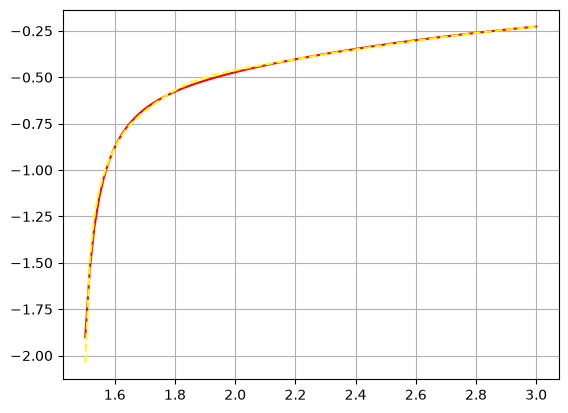

In [14]:
n=2
a = 1-10**(-n)
e=0.00
x=1

plso = get_separatrix(a,e,x)

p = np.linspace(plso+2*DELTAPMIN_REGIONC,3,100)
a=np.ones_like(p)*a
e=np.ones_like(p)*e
x=np.ones_like(p)


pdots = []
edots = []
for aa,pp,ee,xx in zip(a,p,e,x):
    m1,m2 = 10, 10**6
    rhs_nex.add_fixed_parameters(m1, m2, aa)
    pdott,edott,_,_,_,_ = rhs_nex([pp, ee, xx])

    if pdott >0:
        a_near_0, p_near_0 = nearest_ap(aa,pp)[0]
        a_near_1, p_near_1 = nearest_ap(aa,pp)[1]
        Edot_exact, Ldot_exact = check_flux(a_near_0, p_near_0)
       # print(Edot_exact,Ldot_exact)

        pdot_exact, edot_exact = ELdot_to_PEdot_Jacobian(a_near_0,p_near_0,ee,xx,Edot_exact, Ldot_exact)

        if not np.any(np.round(pdot,10) == np.round(pdot_exact,10)):
            #raise ValueError("pdot not in actual pdots")
            print("")

        print(f"At p = {pp}, the interpolant returns a value of {pdott}")
        print(f" The nearest a value is {a_near_0} and p value is {p_near_0}, with the coresponding pdot of {pdot_exact}" )
        print(rf" The 2nd nearest a value is {a_near_1} and p value is {p_near_1}, with the coresponding pdot of {pdot_exact}" )

    pdots.append(pdott)
    edots.append(edott)



  

plt.plot(p,pdot_func(a,p,e,x),color = "red")
plt.plot(p,pdots,"--",color = "yellow")
plt.grid()

In [ ]:
an , pn = 0.9999999999822172 ,1.0737424293378135

ED,LD = check_flux(an,pn)
pdot_func(an, pn,0,1),edot_func(an, pn,0,1) , ELdot_to_PEdot_Jacobian(an, pn,0,1, ED,LD)

(array([0.01038334]), array([-0.]), (0.10999007895749564, 0.0))

In [369]:
np.any(np.round(pgrid,5) == np.round(1.0737424293378135,5)), np.any(np.round(agrid,5) == np.round( 0.99999999998221725,5))

(np.True_, np.True_)

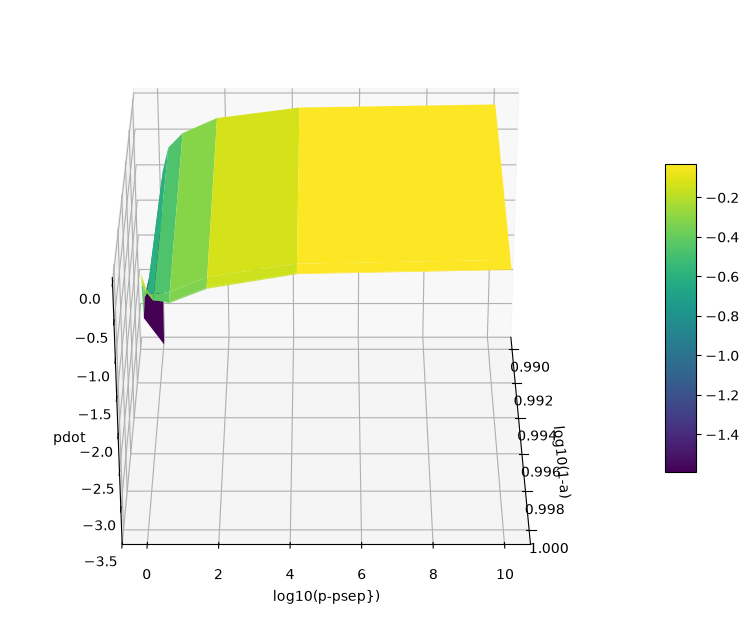

In [372]:
psep = get_separatrix(agrid.reshape(8,9,9)[:,0,:].flatten(), egrid.reshape(8,9,9)[:,0,:].flatten(), np.ones_like(agrid.reshape(8,9,9)[:,0,:]).flatten()).reshape(8,9)

fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(projection='3d')
#surf =ax.plot_surface(np.log10(1-agrid.reshape(8,9,9)[:,0,:]), np.log10(pgrid.reshape(8,9,9)[:,0,:]-psep),- pdot[:,0,:], cmap='viridis')
surf =ax.plot_surface(agrid.reshape(8,9,9)[:,0,:], pgrid.reshape(8,9,9)[:,0,:]-psep,- pdot[:,0,:], cmap='viridis')
ax.set_xlabel('log10(1-a)')
ax.set_ylabel('log10(p-psep})')
ax.set_zlabel('pdot')
ax.view_init(elev=30, azim=0)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.show()

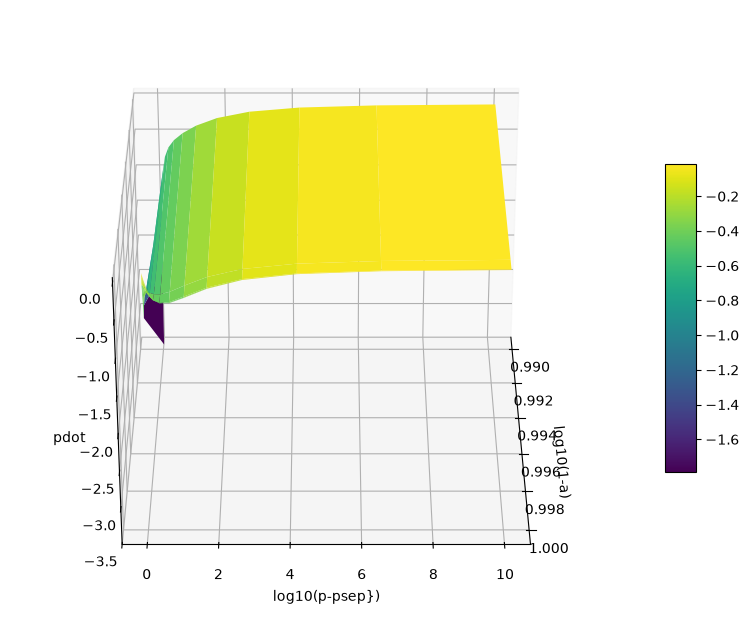

In [10]:
psep = get_separatrix(agrid.reshape(15,9,9)[:,0,:].flatten(), egrid.reshape(15,9,9)[:,0,:].flatten(), np.ones_like(agrid.reshape(15,9,9)[:,0,:]).flatten()).reshape(15,9)

fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(projection='3d')
#surf =ax.plot_surface(np.log10(1-agrid.reshape(15,9,9)[:,0,:]), np.log10(pgrid.reshape(15,9,9)[:,0,:]-psep),- pdot[:,0,:], cmap='viridis')
surf =ax.plot_surface(agrid.reshape(15,9,9)[:,0,:], pgrid.reshape(15,9,9)[:,0,:]-psep,- pdot[:,0,:], cmap='viridis')
ax.set_xlabel('log10(1-a)')
ax.set_ylabel('log10(p-psep})')
ax.set_zlabel('pdot')
ax.view_init(elev=30, azim=0)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.show()

In [ ]:
plt.plot( pgrid.reshape(8,9,9)[:,0,:])

np.False_

In [373]:
agrid.reshape(8,9,9)[0,0,:]

array([0.99      , 0.99943766, 0.99996838, 0.99999822, 0.9999999 ,
       0.99999999, 1.        , 1.        , 1.        ])

In [380]:
pgrid.reshape(8,9,9)[:,8,8]

array([ 1.42371744,  1.45623784,  1.53335585,  1.71623147,  2.14989791,
        3.17828311,  5.61696874, 11.4000037 ])

In [381]:
pgrid.reshape(8,9,9)[:,0,0]

array([ 1.47821168,  1.51073207,  1.58785008,  1.7707257 ,  2.20439215,
        3.23277735,  5.67146297, 11.45449794])

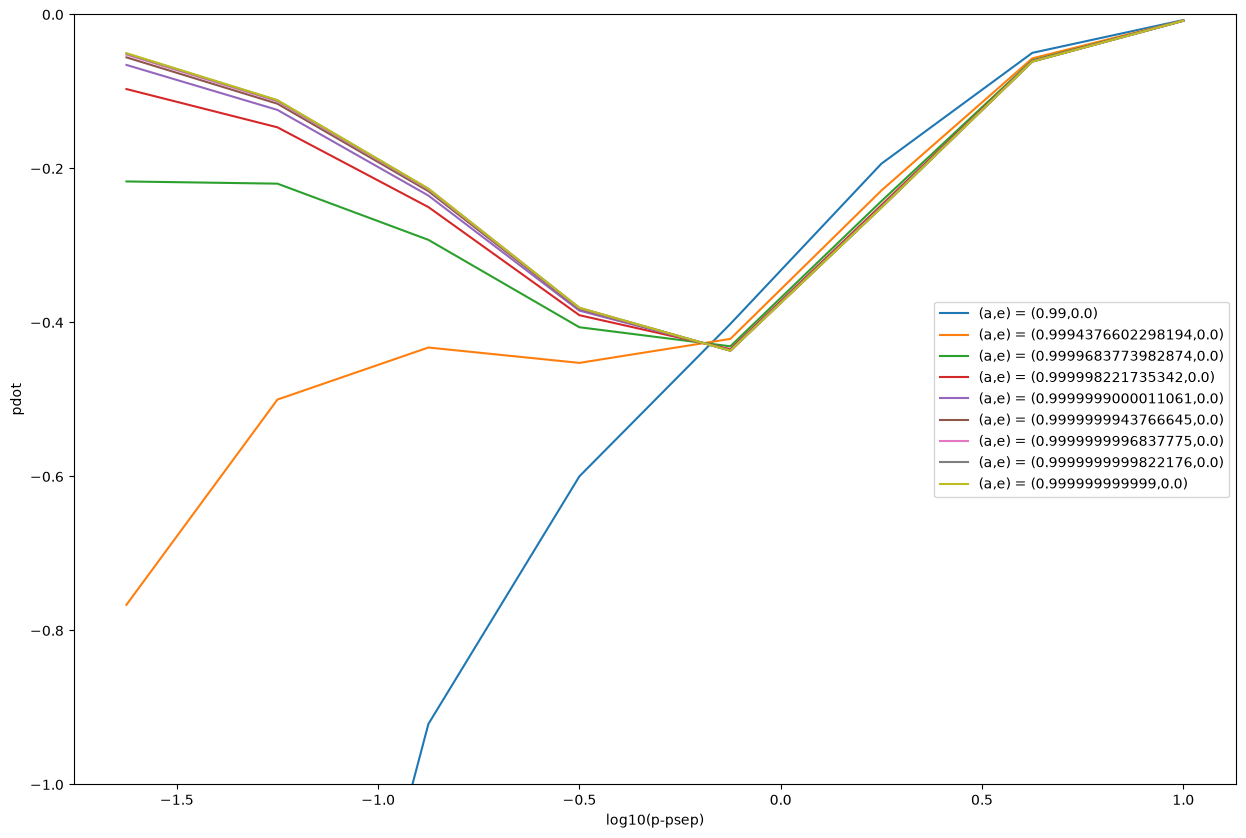

In [436]:
j=0
fig,ax = plt.subplots(1,1,figsize = (15,10))
e =np.arange(0,0.45,0.05)[j]
x=1
for i in range(0,9):
    a = agrid.reshape(8,9,9)[0,j,i]
    sep  = get_separatrix(a,e,x)
    ax.plot(np.log10(pgrid.reshape(8,9,9)[:,j,i]- sep),-pdot.reshape(8,9,9)[:,j,i],label = f"(a,e) = ({a},{e})")

ax.set_ylim(-1,0)
ax.set_xlabel("log10(p-psep)")
ax.set_ylabel("pdot")
ax.legend(fontsize=10,loc = "right")


In [443]:
fig, ax = plt.subplots(figsize=(15, 10))

def update(j):
    ax.clear()
    
    e = np.arange(0, 0.45, 0.05)[j]
    x = 1
    
    for i in range(9):
        a = agrid.reshape(8,9,9)[0,j,i]
        sep = get_separatrix(a, e, x)
        ax.plot(np.log10(pgrid.reshape(8,9,9)[:,j,i] - sep),
                -pdot.reshape(8,9,9)[:,j,i],
                label=f"(a,e)=({a},{e:.3f})")

    ax.set_ylim(-1, 0)
    ax.set_xlabel("log10(p-psep)")
    ax.set_ylabel("pdot")
    ax.set_title(f"e = {e:.2f}")
    ax.legend(fontsize=8, loc="right")
    ax.grid()

ani = FuncAnimation(fig, update, frames=9, interval=500)

ani.save("separatrix.gif", writer=PillowWriter(fps=1))
plt.close()

In [ ]:
agrid.reshape(8,9,9)[0,7,5]

array([0.99999999, 0.99999999, 0.99999999, 0.99999999, 0.99999999,
       0.99999999, 0.99999999, 0.99999999])

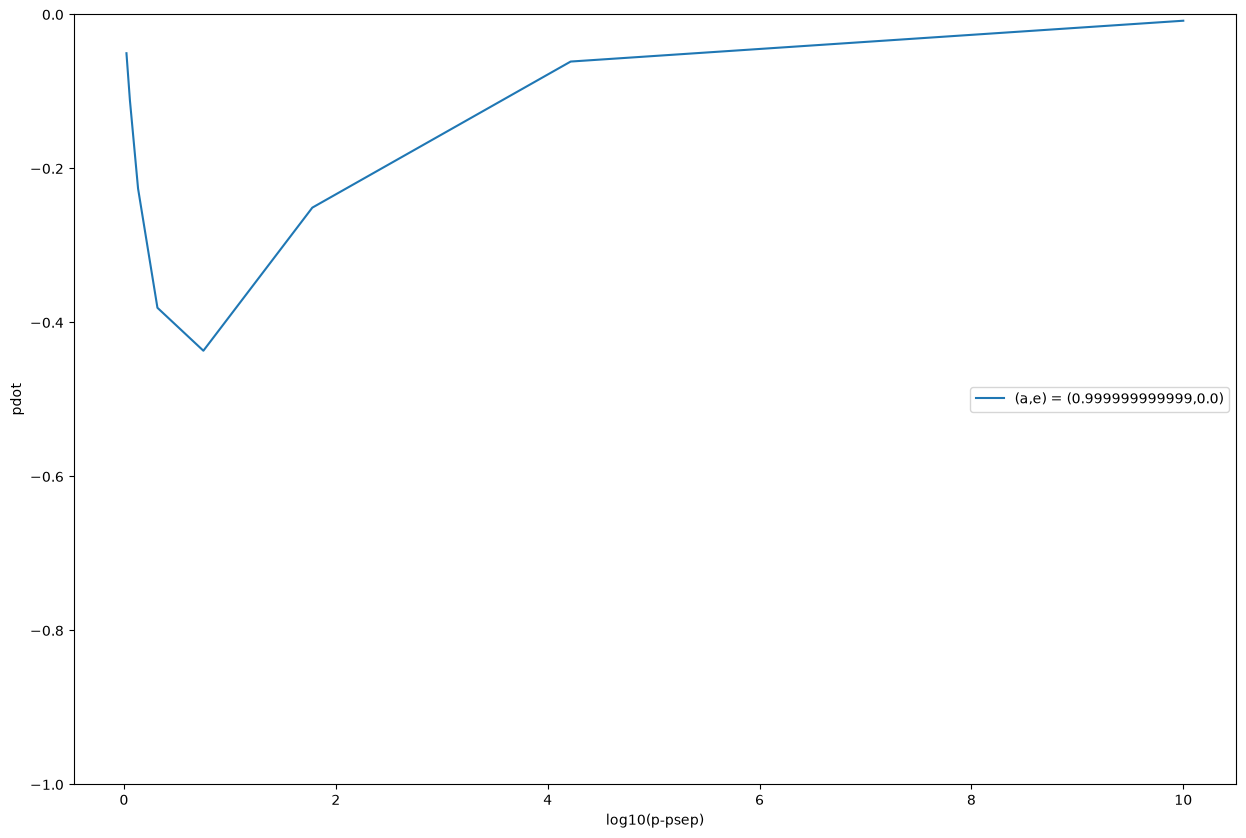

In [453]:
j=0
fig,ax = plt.subplots(1,1,figsize = (15,10))
e =np.arange(0,0.45,0.05)[j]
x=1
for i in range(8,9):
    a = agrid.reshape(8,9,9)[:,j,i]
    p = pgrid.reshape(8,9,9)[:,j,i]
    e = np.ones_like(p)*e
    x = np.ones_like(p)
    sep  = get_separatrix(a,e,x)
    ax.plot(p- sep,pdot_func(a,p,e,x),label = f"(a,e) = ({a[0]},{e[0]})")

ax.set_ylim(-1,0)
ax.set_xlabel("log10(p-psep)")
ax.set_ylabel("pdot")
ax.legend(fontsize=10,loc = "right")
